# Notebook de Entrenamiento: Reconocimiento Facial

## Equipo
- Alumno 1: Juan Andres Morales
- Alumno 2: Genaro Canciani

## 1. Configuración e Instalación
Instalamos las librerías necesarias para el preprocesamiento y entrenamiento.

El código de las siguientes celdas funciona para ejecutar el entrenamiento usando una GPU NVIDIA mediante cuda. En el caso de no contar con una GPU NVIDIA, mantener comentado. 

In [ ]:
# Librerías estándar
import math
import os
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Computer Vision
import cv2
from PIL import Image
from tqdm import tqdm

# Scikit-Learn
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# InsightFace
from insightface.app import FaceAnalysis
from insightface.utils import face_align

In [6]:
# import subprocess, sys
# subprocess.run([
#     "uv", "pip", "install",
#     "torch", "torchvision", "torchaudio",
#     "--index-url", "https://download.pytorch.org/whl/cu124",
#     "--upgrade"
# ], check=True)

In [7]:
# import torch
# print(torch.__version__)              
# print(torch.cuda.is_available())       
# print(torch.cuda.get_device_name(0))   

## 2. Descarga del Dataset LFW
Descargamos el dataset Labeled Faces in the Wild, filtrando aquellas personas que tengan al menos 20 imágenes para asegurar suficientes datos de entrenamiento por clase.

In [ ]:
# Descargamos LFW (esto puede tardar unos segundos la primera vez)
lfw = fetch_lfw_people(min_faces_per_person=20, resize=1.0, color=True, slice_=None)
n_samples, h, w, c = lfw.images.shape
n_classes = len(lfw.target_names)

print(f"Total de imágenes originales: {n_samples}")
print(f"Cantidad de personas (clases): {n_classes}")
print(f"Resolución original: {h}x{w}")

Total de imágenes originales: 3023
Cantidad de personas (clases): 62
Resolución original: 250x250


## 3. Preprocesamiento (Alineación con InsightFace)
**Justificación:** Extraemos únicamente la zona del rostro y lo alineamos usando los landmarks de InsightFace o un fallback de bounding box si los landmarks fallan. Esto reduce el ruido de fondo y garantiza que la red se enfoque puramente en la identidad facial, siendo robusto a las limitaciones de detección del hardware.

In [ ]:
from insightface.app import FaceAnalysis
from insightface.utils import face_align
import cv2
from tqdm import tqdm
import numpy as np
import os

# Inicialización de Insight Face
print("Inicializando InsightFace (CPU)...")
app = FaceAnalysis(name='buffalo_l', providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
app.prepare(ctx_id=0)

def safe_crop_face(img_bgr, face):
    if face.kps is not None:
        aligned = face_align.norm_crop(img_bgr, landmark=face.kps, image_size=112)
        if aligned is not None and aligned.size > 0:
            return aligned
    
    if face.bbox is not None:
        x1, y1, x2, y2 = face.bbox.astype(int)
        h, w = img_bgr.shape[:2]
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w, x2), min(h, y2)
        
        crop = img_bgr[y1:y2, x1:x2]
        if crop.size > 0:
            return cv2.resize(crop, (112, 112))
    return None

procesado_img_path = 'lfw_clean_images.npy'
procesado_lbl_path = 'lfw_clean_labels.npy'

if os.path.exists(procesado_img_path) and os.path.exists(procesado_lbl_path):
    print("¡Archivos encontrados! Cargando imágenes procesadas directamente desde el disco...")
    clean_images = list(np.load(procesado_img_path))
    clean_labels = list(np.load(procesado_lbl_path))
    print(f"LFW cargado exitosamente: {len(clean_images)} imágenes")

else:
    print("No se encontraron archivos en disco. Procesando LFW...")
    clean_images = []
    clean_labels = []

    print("Procesando y alineando LFW...")
    for i in tqdm(range(n_samples)):
        img_rgb = (lfw.images[i] * 255).astype(np.uint8)
        img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
        
        faces = app.get(img_bgr)
        if len(faces) > 0:
            face = faces[0]
            aligned_face_bgr = safe_crop_face(img_bgr, face)
            
            if aligned_face_bgr is not None:
                aligned_face_rgb = cv2.cvtColor(aligned_face_bgr, cv2.COLOR_BGR2RGB)
                clean_images.append(aligned_face_rgb)
                clean_labels.append(lfw.target[i])

    print(f"\nLFW procesado exitosamente: {len(clean_images)} de {n_samples}")
    
    print("Guardando imágenes procesadas en disco para futuros usos...")
    np.save(procesado_img_path, np.array(clean_images))
    np.save(procesado_lbl_path, np.array(clean_labels))
    print("¡Guardado completado!")

Inicializando InsightFace (CPU)...
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/gena/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/gena/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/gena/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/gena/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/gena/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3,

### Dataset Propio
Procesamos nuestro dataset propio usando la misma lógica de recorte robusto.

In [10]:
import os
from pathlib import Path

custom_data_path = Path("src/data/dataset_propio") 
custom_images = []
custom_labels = []
current_label_id = n_classes 
custom_target_names = []

if custom_data_path.exists():
    print("Procesando dataset propio...")
    for person_folder in custom_data_path.iterdir():
        if person_folder.is_dir():
            person_name = person_folder.name
            custom_target_names.append(person_name)
            
            archivos = list(person_folder.glob("*.jpg")) + list(person_folder.glob("*.png")) + list(person_folder.glob("*.jpeg"))
            
            for img_path in archivos:
                img_bgr = cv2.imread(str(img_path))
                if img_bgr is None: continue
                
                faces = app.get(img_bgr)
                if len(faces) > 0:
                    face = faces[0]
                    aligned_face_bgr = safe_crop_face(img_bgr, face)
                    
                    if aligned_face_bgr is not None:
                        aligned_face_rgb = cv2.cvtColor(aligned_face_bgr, cv2.COLOR_BGR2RGB)
                        custom_images.append(aligned_face_rgb)
                        custom_labels.append(current_label_id)
            
            current_label_id += 1
            
    print(f"Caras propias procesadas y alineadas: {len(custom_images)}")
else:
    print("No se encontró la carpeta del dataset propio.")

all_images = clean_images + custom_images
all_labels = clean_labels + custom_labels
all_target_names = list(lfw.target_names) + custom_target_names

print(f"\nTotal final de imágenes listas para entrenar: {len(all_images)}")
print(f"Total de personas distintas (clases): {len(all_target_names)}")

Procesando dataset propio...
Caras propias procesadas y alineadas: 80

Total final de imágenes listas para entrenar: 3093
Total de personas distintas (clases): 71


## 4. Dataloaders y Data Augmentation
**Justificación:** Agregamos Data Augmentation (Flip, Rotación, ColorJitter) para aumentar la diversidad de las caras de nuestro dataset propio y reducir el sobreajuste (overfitting). Utilizamos las medias y desviaciones estándar requeridas por los modelos pre-entrenados en ImageNet.

In [ ]:
class FaceDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        
        # PIL Image es requerido por algunas transformaciones
        image = Image.fromarray(image)
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Transformaciones para entrenamiento (Data Augmentation)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Transformaciones para validación 
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

X_train, X_val, y_train, y_val = train_test_split(
    all_images, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

train_dataset = FaceDataset(X_train, y_train, transform=train_transform)
val_dataset = FaceDataset(X_val, y_val, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,drop_last= True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Tamaño del set de entrenamiento: {len(train_dataset)}")
print(f"Tamaño del set de validación: {len(val_dataset)}")


Tamaño del set de entrenamiento: 2474
Tamaño del set de validación: 619


In [ ]:
class ArcFace(nn.Module):
    def __init__(self, in_features, out_features, s=30.0, m=0.50):
        super(ArcFace, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.s = s
        self.m = m
        self.weight = nn.Parameter(torch.FloatTensor(out_features, in_features))
        nn.init.xavier_uniform_(self.weight)

        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, input, label):
        cosine = F.linear(F.normalize(input), F.normalize(self.weight))
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2).clamp(0, 1))
        
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        
        one_hot = torch.zeros(cosine.size(), device=input.device)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        
        output *= self.s
        return output

## 5. Arquitectura del Modelo (ResNet50 + Fine Tuning)
*Justificación Técnica*: Seleccionamos ResNet50 como backbone extractor de características, aprovechando sus pesos pre-entrenados (Transfer Learning) para una convergencia rápida y evitar el sobreajuste. Sin embargo, reemplazamos la clásica capa lineal de clasificación por un módulo ArcFace (Additive Angular Margin Loss). Mientras que la pérdida de entropía cruzada estándar (Cross-Entropy) agrupa las clases de forma débil, ArcFace impone un estricto margen angular matemático entre las distintas identidades durante el entrenamiento. Esto fuerza a la red a agrupar los rostros de una misma persona de forma extremadamente compacta (intra-class compactness) y a alejar radicalmente los clusters de personas diferentes en el espacio latente (inter-class discrepancy). El resultado final es un modelo que extrae embeddings de 512 dimensiones altamente discriminativos, reduciendo drásticamente los falsos positivos y siendo ideal para sistemas de reconocimiento facial de conjunto abierto (Open-Set).

In [ ]:
class FaceRecognitionResNet(nn.Module):
    def __init__(self):
        super(FaceRecognitionResNet, self).__init__()
        self.backbone = models.resnet50(weights='DEFAULT')
        
        num_ftrs = self.backbone.fc.in_features
        
        # QUITAMOS la última capa Linear. Ahora el modelo devuelve el embedding directo.
        self.backbone.fc = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        
    def forward(self, x):
        # Normalizamos el embedding que sale de la red
        x = self.backbone(x)
        return torch.nn.functional.normalize(x, p=2, dim=1)
        
    def extract_embedding(self, x):
        # En inferencia, solo necesitamos el forward normal
        return self.forward(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

model = FaceRecognitionResNet()
model = model.to(device)

# Inicializamos ArcFace
arcface = ArcFace(in_features=512, out_features=len(all_target_names), s=30.0, m=0.50)
arcface = arcface.to(device)

Usando dispositivo: cpu


## 6. Bucle de Entrenamiento (Training Loop)
Ajustamos los pesos del modelo. Usamos `ArcFace` y el optimizador `Adam`.En este caso se realiza un Fine Tuning de la arquitectura completa para que el modelo (previamente entrenado con ImageNet, no para la detección facial) pueda adaptarse a extraer características de rostros. Se toma la decisión de utilizar un lr de 1e-4 para no destruir las características generales ya aprendidas por el modelo. 

La poca cantidad de épocas se debe a la rápida convergencia del modelo, logrando alcanzar una accuracy en validación de 92% en la primera iteración del loop de entrenamiento. 

In [ ]:
import torch.optim as optim
import time

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

criterion = nn.CrossEntropyLoss()

# El optimizador ahora recibe los parámetros del modelo Y de ArcFace
optimizer = optim.Adam([
    {'params': model.parameters()},
    {'params': arcface.parameters()}
], lr=0.0001)

num_epochs = 50

print("Iniciando entrenamiento con ArcFace...")
for epoch in range(num_epochs):
    start_time = time.time()
    model.train()
    arcface.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        embeddings = model(inputs)
        # Pasamos embeddings y labels por ArcFace antes de calcular la loss
        outputs = arcface(embeddings, labels)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
    train_acc = 100 * correct / total
    
    # Validación
    model.eval()
    arcface.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            embeddings = model(inputs)
            outputs = arcface(embeddings, labels)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
            
    val_acc = 100 * val_correct / val_total
    epoch_time = time.time() - start_time
    
    print(f"Época [{epoch+1}/{num_epochs}] - Tiempo: {epoch_time:.0f}s - "
          f"Loss: {running_loss/len(train_loader):.4f} - Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss/len(val_loader):.4f} - Val Acc: {val_acc:.2f}%")

Iniciando entrenamiento con ArcFace...
Época [1/25] - Tiempo: 71s - Loss: 18.4781 - Acc: 0.00% | Val Loss: 16.1709 - Val Acc: 0.97%
Época [2/25] - Tiempo: 74s - Loss: 15.4943 - Acc: 2.19% | Val Loss: 12.7861 - Val Acc: 23.26%
Época [3/25] - Tiempo: 74s - Loss: 13.0256 - Acc: 13.60% | Val Loss: 10.7259 - Val Acc: 27.46%
Época [4/25] - Tiempo: 72s - Loss: 11.2801 - Acc: 18.99% | Val Loss: 9.0322 - Val Acc: 35.06%
Época [5/25] - Tiempo: 72s - Loss: 9.7596 - Acc: 21.47% | Val Loss: 7.3245 - Val Acc: 43.46%
Época [6/25] - Tiempo: 73s - Loss: 8.4785 - Acc: 24.23% | Val Loss: 5.9726 - Val Acc: 49.92%
Época [7/25] - Tiempo: 72s - Loss: 7.2368 - Acc: 26.54% | Val Loss: 4.8133 - Val Acc: 57.67%
Época [8/25] - Tiempo: 71s - Loss: 6.3436 - Acc: 28.98% | Val Loss: 3.7654 - Val Acc: 64.46%
Época [9/25] - Tiempo: 71s - Loss: 5.4856 - Acc: 31.86% | Val Loss: 3.2870 - Val Acc: 71.57%
Época [10/25] - Tiempo: 71s - Loss: 4.8224 - Acc: 34.90% | Val Loss: 2.7354 - Val Acc: 75.44%
Época [11/25] - Tiempo: 68

## 7. Evaluación: Métricas y Embeddings (PCA / t-SNE)
Validamos que el modelo haya aprendido a separar las identidades en el espacio vectorial.

In [ ]:
# Pasamos el dataset de validación por el modelo para obtener métricas
model.eval()
all_preds = []
all_labels_val = []
all_embeddings = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device) # Mover labels a gpu
        
        # El modelo solo saca los 512 números (el embedding)
        embeddings = model(inputs)
        
        # ArcFace compara esos 512 números contra los 71 centros de identidades
        outputs = arcface(embeddings, labels)
        
        # sacamos el índice de la persona con mayor probabilidad (0 a 70)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels_val.extend(labels.cpu().numpy())
        all_embeddings.extend(embeddings.cpu().numpy())

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         8
           1       0.86      0.86      0.86         7
           2       0.60      0.75      0.67         4
           3       0.88      1.00      0.93         7
           4       1.00      0.25      0.40         4
           5       1.00      0.94      0.97        16
           6       0.89      1.00      0.94         8
           7       0.83      1.00      0.91         5
           8       1.00      1.00      1.00         6
           9       0.50      0.75      0.60         4
          10       1.00      0.98      0.99        47
          11       0.60      1.00      0.75         6
          12       1.00      1.00      1.00        24
          13       0.00      0.00      0.00         4
          14       0.98      0.98      0.98       106
          15       0.81      1.00      0.90        22
          16       1.00      0.89      0.94         9
    

Calculando t-SNE en 2D...


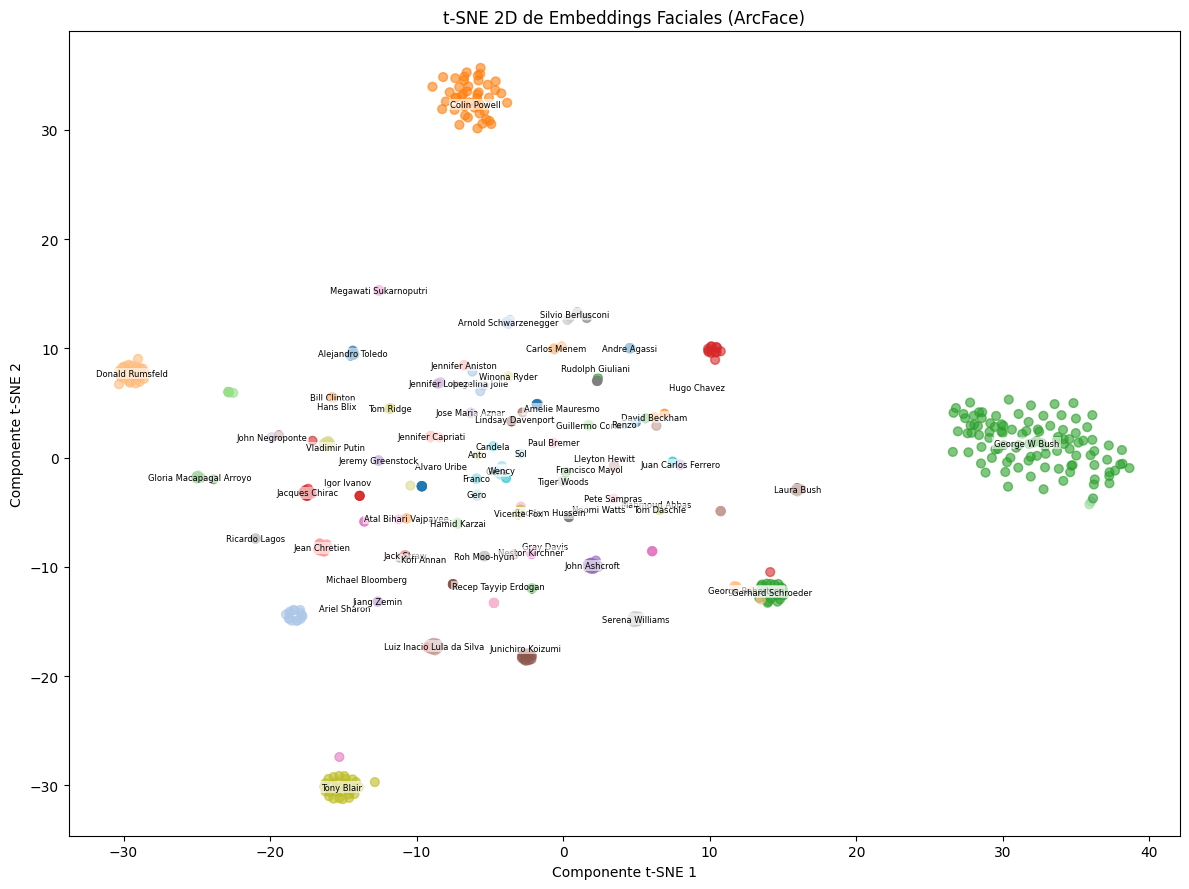

In [ ]:
# Convertimos a arrays 
all_embeddings_np = np.array(all_embeddings)
all_labels_np = np.array(all_labels_val)

print("Calculando t-SNE en 2D...")
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
tsne_result = tsne.fit_transform(all_embeddings_np)

plt.figure(figsize=(12, 9))

# Dibujamos los puntos
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=all_labels_np, cmap='tab20', alpha=0.6, s=40)

# Agregamos los nombres en el centro de cada cluster
for i in np.unique(all_labels_np):
    idx = all_labels_np == i
    
    # Centro aproximado de los puntos de esta persona
    x_center = np.mean(tsne_result[idx, 0])
    y_center = np.mean(tsne_result[idx, 1])
    
    nombre = all_target_names[i]
    

    plt.text(x_center, y_center, nombre, fontsize=6, ha='center', va='center', 
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=1))

plt.title("t-SNE 2D de Embeddings Faciales (ArcFace)")
plt.xlabel("Componente t-SNE 1")
plt.ylabel("Componente t-SNE 2")
plt.tight_layout()
plt.show()

El modelo logra separar la mayoría de las clases de manera satisfactoria aunque no perfecta, teniendo algunas superposiciones de embeddings, sobre todo en clases cuya cantidad de muestras disponibles en el dataset es poca.

Calculando matriz de similitudes (Todos vs Todos)...
 Micro Rank-1 (Global, influenciado por clases grandes):     95.32%
 Macro Rank-1 (Promedio por clases, justo para desbalance): 91.07%

Calculando Curva ROC y AUC...


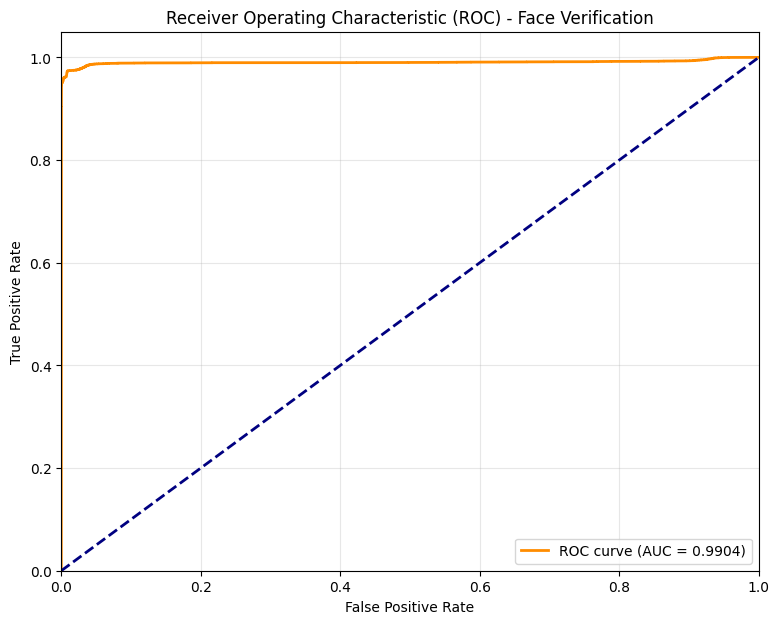

In [22]:
print("Calculando matriz de similitudes (Todos vs Todos)...")
# Calculamos la similitud coseno entre todas las imágenes del set de validación
sim_matrix = cosine_similarity(all_embeddings_np)

# Matriz de "Ground Truth": True si el par es de la misma persona, False si no
match_matrix = (all_labels_np[:, None] == all_labels_np[None, :])


np.fill_diagonal(sim_matrix, -1.0)

# Para cada imagen, obtenemos el índice de la imagen con la similitud más alta
closest_indices = np.argmax(sim_matrix, axis=1)

# Comparamos si la etiqueta de esa imagen "más cercana" es igual a la etiqueta real
correct_matches = (all_labels_np[closest_indices] == all_labels_np)
micro_rank1 = np.mean(correct_matches) * 100

print(f" Micro Rank-1 (Global, influenciado por clases grandes):     {micro_rank1:.2f}%")


# Macro Average
unique_labels = np.unique(all_labels_np)
class_accuracies = []

for label in unique_labels:
    idx = (all_labels_np == label)
    acc_for_this_person = np.mean(correct_matches[idx])
    class_accuracies.append(acc_for_this_person)

macro_rank1 = np.mean(class_accuracies) * 100

print(f" Macro Rank-1 (Promedio por clases, justo para desbalance): {macro_rank1:.2f}%\n")

# Curva Roc
print("Calculando Curva ROC y AUC...")
# Obtenemos solo el triángulo superior de la matriz para evitar medir pares duplicados 
upper_tri_indices = np.triu_indices_from(sim_matrix, k=1)

# Extraemos las puntuaciones y las verdades reales de esos pares únicos
scores = sim_matrix[upper_tri_indices]
y_true = match_matrix[upper_tri_indices].astype(int)

# Calculamos FPR (False Positive Rate) y TPR (True Positive Rate)
fpr, tpr, thresholds = roc_curve(y_true, scores)
roc_auc = auc(fpr, tpr)

# Dibujamos el gráfico
plt.figure(figsize=(9, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Face Verification')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Teniendo en cuenta que se va a trabajar con reconocimiento facial, se considera que la métrica mas importante para evaluar el correcto funcionamiento de los embeddings es la métrica  Rank-1. La misma compara un embedding con todos los demás en en espacio vectorial y determina si la clasificación fue correcta dependiendo de la etiqueta del embedding más similar. En este caso, como queremos que el modelo logre identificar correctemente las identidades, el rank-1 en similitud siempre va a ser nuestra prioridad, pues es el que determina que etiqueta se va a asignar. 

Se decide utilizar las variaciones Macro y Micro de dicha métrica, para poder observar como se comporta en modelo en general, y como se comporta cuando se promedia el rendimiento de todas las clases.

El gráfico de la curva Roc da un resultado casi perfecto, con un AUC que es muy cercana a 1. 

En conclusión, las métricas demuestran que el modelo logra una buena separación y comparación de embeddings, acertando en la gran mayoría de los casos la identidad del embedding ingresado. 


## 8. Guardar el Modelo para el Backend
Exportamos el archivo `.onnx` en la carpeta `models/` para que el backend (`face_service.py`) lo pueda levantar.

In [18]:
import os
import torch

# 1. Preparamos el modelo original (que ya tiene los pesos entrenados)
model.eval() # Modo evaluación (apaga el Dropout)
model.cpu()  # Lo pasamos a la memoria RAM normal para exportar

# 2. Rutas de los archivos
onnx_path = 'models/face_detection.onnx'
data_path = 'models/face_detection.onnx.data'

# 3. Eliminamos los modelos viejos para evitar conflictos de archivos .data
if os.path.exists(onnx_path):
    os.remove(onnx_path)
if os.path.exists(data_path):
    os.remove(data_path)
print("🗑️ Modelos anteriores eliminados.")

# 4. Creamos el tensor de prueba para rastrear la arquitectura
dummy_input = torch.randn(1, 3, 112, 112)

# 5. Exportamos el modelo DIRECTAMENTE
torch.onnx.export(
    model,                # Usamos el modelo entrenado directamente
    dummy_input,
    onnx_path,
    export_params=True,   # Guarda los pesos entrenados dentro del archivo
    opset_version=14,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    }
)

print(f"✅ ¡Nuevo modelo entrenado exportado limpiamente a {onnx_path}!")

🗑️ Modelos anteriores eliminados.


/tmp/ipykernel_114851/791970785.py:23: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0428 20:57:16.833000 114851 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 14 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `FaceRecognitionResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `FaceRecognitionResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 14).
Failed to convert the model to the target version 14 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/media/gena/Disco Local/Facultad/CUATRI 5/CV/tuia-face-recognition-app/.venv/lib/python3.12/site-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/media/gena/Disco Local/Facultad/CUATRI 5/CV/tuia-face-recognition-app/.venv/lib/python3.12/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
✅ ¡Nuevo modelo entrenado exportado limpiamente a models/face_detection.onnx!


# Carga dataset propio a base de datos 

In [19]:
# import requests
# import time
# from pathlib import Path

# # Configuración de tu backend local
# BACKEND_URL = "http://localhost:8000"
# # Ruta a tu dataset propio (ajustar si es necesario)
# custom_data_path = Path("src/data/dataset_propio")

# def registrar_identidades_en_bd():
#     if not custom_data_path.exists():
#         print(f"La ruta {custom_data_path} no existe.")
#         return

#     print("Iniciando la carga de embeddings a la base de datos vía API...")
    
#     for person_folder in custom_data_path.iterdir():
#         if person_folder.is_dir():
#             identity = person_folder.name
            
#             # Tomar todas las imágenes de la persona
#             archivos = list(person_folder.glob("*.jpg")) + list(person_folder.glob("*.png")) + list(person_folder.glob("*.jpeg"))
            
#             for img_path in archivos:
#                 # 1. Armamos el payload esperado por el endpoint /insert
#                 payload = {
#                     "identity": identity,
#                     "image_path": str(img_path.absolute()), # La API necesita un path absoluto o válido
#                     "metadata": {"fuente": "dataset_propio", "notebook_sync": True}
#                 }
                
#                 try:
#                     # 2. Hacemos el POST al endpoint asincrónico
#                     response = requests.post(f"{BACKEND_URL}/insert", json=payload)
                    
#                     if response.status_code == 202:
#                         job_id = response.json().get("job_id")
#                         print(f"[{identity}] Job encolado con ID: {job_id} para la imagen {img_path.name}")
                        
#                         # Opcional: Podrías hacer polling al /status/{job_id} para asegurarte de que terminó, 
#                         # pero al ser una carga inicial, basta con enviarlos todos.
#                         time.sleep(0.1) # Pequeño delay para no saturar el TaskManager del backend
#                     else:
#                         print(f"Error al registrar {identity}: {response.text}")
                        
#                 except requests.exceptions.ConnectionError:
#                     print("Error de conexión: Asegúrate de que el backend esté corriendo en http://localhost:8000")
#                     return

#     print("\n¡Proceso de registro finalizado!")

# # Llamar a la función para registrar
# registrar_identidades_en_bd()